In [2]:
print("Hi")

Hi


# Placement Analysis
This project analyzes student placement data

This project contains the following structure

1. Title + Introduction
2. Load Data
3. Data Understanding
4. Data Preprocessing
5. Visualization
6. Model Building
7. Evaluation
8. Insights (MOST IMPORTANT)

# Campus Placement Prediction & Analysis

## Objective
To analyze student data and predict placement status using machine learning models.

## Approach
- Data preprocessing
- Statistical analysis
- Logistic Regression
- Support Vector Machine (SVM)
- Model comparison

## Dataset
Student placement dataset containing CGPA, skills, internships, etc.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv('placementdata.csv')

data.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [4]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  object 
 8   PlacementTraining          10000 non-null  object 
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  object 
dtypes: float64(2), int64(7), object(3)
memory usage: 937.6+ KB


,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,7.698010,1.049200,2.026600,1.013200,79.449900,4.323960,69.159400,74.501500
std,2886.89568,0.640131,0.665901,0.867968,0.904272,8.159997,0.411622,10.430459,8.919527
min,1.00000,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,55.000000,57.000000
25%,2500.75000,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,59.000000,67.000000
50%,5000.50000,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,70.000000,73.000000
75%,7500.25000,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,78.000000,83.000000
max,10000.00000,9.100000,2.000000,3.000000,3.000000,90.000000,4.800000,90.000000,88.000000


Here, 
SSC is mean by Secondary School Certificate. (10th standard marks)
HSC is mean by Higher Secondary Certificate. (12th standard marks)

## Data Understanding

- Dataset contains academic and skill-based features
- Target variable: PlacementStatus
- Includes both numerical and categorical data

In [5]:
data['ExtracurricularActivities'] = data['ExtracurricularActivities'].map({'Yes':1, 'No':0})
data['PlacementTraining'] = data['PlacementTraining'].map({'Yes':1, 'No':0})
data['PlacementStatus'] = data['PlacementStatus'].map({'Placed':1, 'NotPlaced':0})

data = data.drop(columns=['StudentID'])

## Data Preprocessing

- Converted categorical values to numerical
- Removed unnecessary columns
- Prepared data for machine learning models

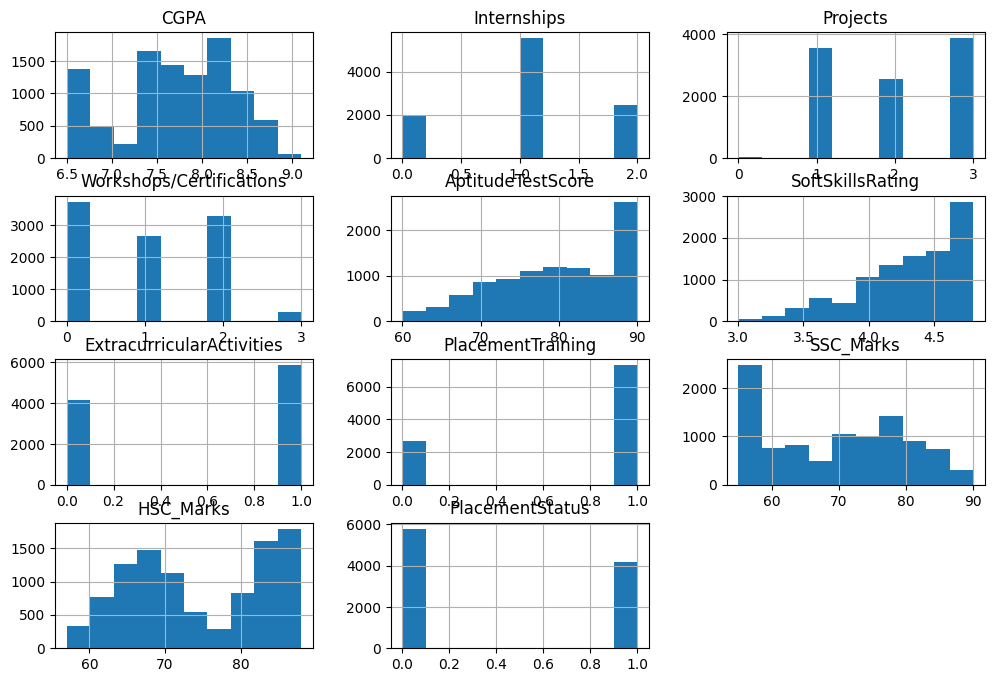

In [6]:
data.hist(figsize=(12,8))
plt.show()

## Feature Distribution Analysis

- CGPA is mostly concentrated between 7–8.5 indicating moderate to strong academic performance
- Internship and project counts show students have some practical exposure
- Aptitude scores follow a near-normal distribution
- Soft skills are generally above average
- Placement training is a significant feature as most students have undergone training
- Academic scores (SSC & HSC) show moderate variation
- Placement status is binary with slight imbalance

These distributions help understand the dataset and guide model building decisions.

DEFINING FEATURES

In [7]:
X = data.drop(columns=['PlacementStatus'])
Y = data['PlacementStatus']

NORMALIZATION

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Feature Scaling

- Applied Z-score normalization
- Ensures all features contribute equally

LOGISTIC REGRESSION

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model = LogisticRegression()
log_model.fit(X_scaled, Y)

log_pred = log_model.predict(X_scaled)

print("Logistic Accuracy:", accuracy_score(Y, log_pred))

Logistic Accuracy: 0.799


## Logistic Regression Performance

The logistic regression model achieved an accuracy of approximately 80%.
This indicates that the model is able to capture the relationship between features and placement status effectively.
However, accuracy alone is not sufficient, and further evaluation using confusion matrix and other metrics is necessary.
The performance is comparable to SVM, suggesting that the dataset is approximately linearly separable.

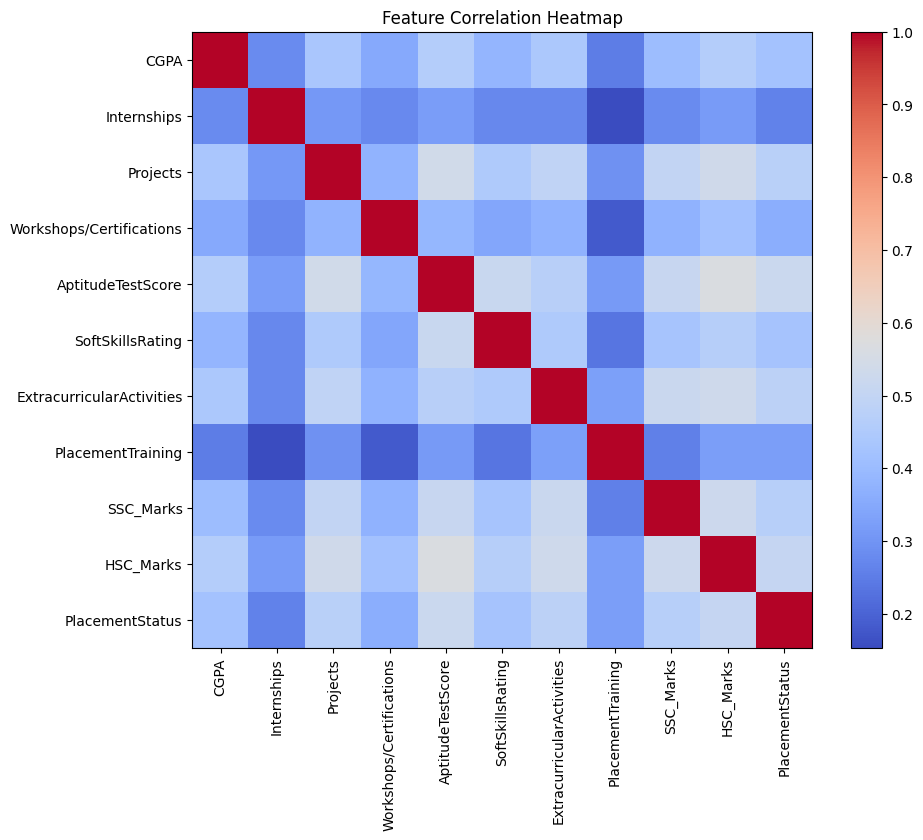

In [10]:
corr = data.corr()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Feature Correlation Heatmap")
plt.show()

## Correlation Analysis Insights

- CGPA, Projects, Aptitude Test Score, and academic marks show moderate correlation with placement status
- Soft skills and extracurricular activities also contribute but to a lesser extent
- Some features like internships show weaker correlation in this dataset
- Strong correlation between SSC and HSC marks indicates consistent academic performance
- Combining multiple features improves prediction performance

This analysis helps in understanding feature importance and improving model effectiveness.

SVM 

In [16]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear')
svm_model.fit(X_scaled, Y)

svm_pred = svm_model.predict(X_scaled)
print("SVM Accuracy:", accuracy_score(Y, svm_pred))

SVM Accuracy: 0.799


Confusion matrix

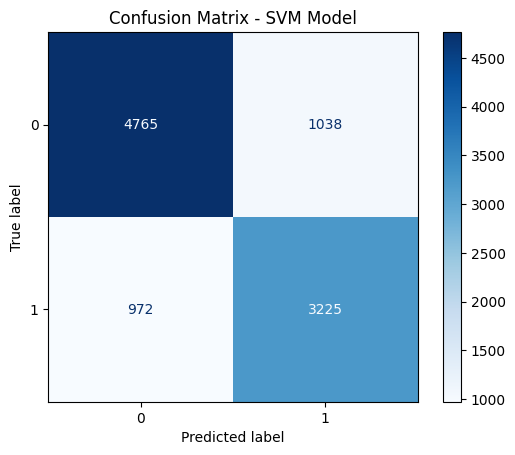

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(Y, svm_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix - SVM Model")
plt.show()

## Confusion Matrix Analysis

- True Negatives (4765): Correctly predicted non-placed students
- True Positives (3225): Correctly predicted placed students
- False Positives (1038): Incorrectly predicted placement
- False Negatives (972): Missed actual placements

The model performs well overall with ~80% accuracy, but some misclassification exists, especially in borderline cases.

This indicates that while the model captures general patterns, placement prediction is influenced by multiple overlapping factors.

In [14]:
print("Logistic:", accuracy_score(Y, log_pred))
print("SVM:", accuracy_score(Y, svm_pred))

Logistic: 0.799
SVM: 0.799


## Model Comparison

Both Logistic Regression and SVM achieved approximately 80% accuracy.

This indicates that the dataset is largely linearly separable, and increasing model complexity does not significantly improve performance.

Hence, simpler models are sufficient for this problem.

SVM Accuracy when the RBF (Radial Basis Function) kernel is used not linear kernel.

In [18]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf')
svm_model.fit(X_scaled, Y)

svm_pred = svm_model.predict(X_scaled)
print("SVM Accuracy when rbf kernel is used:", accuracy_score(Y, svm_pred))

SVM Accuracy when rbf kernel is used: 0.8088


## SVM Kernel Comparison

- Linear kernel achieved ~80% accuracy
- RBF kernel improved accuracy to ~80.9%

This suggests that the dataset contains some non-linear patterns, which are better captured by the RBF kernel.
Hence, RBF provides slightly better performance than linear models.

## Model Evaluation

The performance of the models was evaluated using multiple metrics including accuracy, confusion matrix, and classification report.

- Logistic Regression achieved an accuracy of approximately 80%
- SVM with linear kernel achieved similar performance (~80%)
- SVM with RBF kernel slightly improved the accuracy to ~80.88%

This indicates that both linear and non-linear models perform well on the dataset, with a slight advantage for the RBF kernel.

It is important to note that accuracy alone is not sufficient to evaluate a model. Therefore, confusion matrix and classification metrics such as precision, recall, and F1-score were also analyzed to understand model performance in detail.

In [26]:
data['Prediction'] = svm_pred
data.to_csv('output_Placement_Predictions.csv', index=False)

print("✅ Predictions saved successfully")

OSError: [Errno 22] Invalid argument: 'output_Placement_Predictions.csv'

## Key Insights

- The dataset is largely linearly separable, as both Logistic Regression and linear SVM achieved similar performance
- The slight improvement using RBF kernel suggests the presence of some non-linear patterns in the data
- Placement prediction is influenced by multiple factors rather than a single dominant feature
- Feature scaling played a crucial role in improving model performance
- The model achieves around 80% accuracy, which is considered good for real-world datasets with inherent variability
- Misclassifications occur due to overlapping feature distributions and hidden factors not present in the dataset

## Final Conclusion

This project demonstrates how machine learning models can be applied to real-world placement data to generate meaningful predictions and insights.

The results show that simpler models can perform effectively, while more advanced models like SVM with RBF kernel provide slight improvements by capturing non-linear relationships.

Overall, the model performs well with approximately 80% accuracy, indicating a good balance between simplicity and predictive performance.